# RDF N-Triples Analysis Notebook using rdflib


In [1]:
name = "organization"

# =========================

# 1. Setup

# =========================


In [2]:
from rdflib import Graph, URIRef, Literal, Namespace
from rdflib.namespace import RDF, RDFS, SKOS, XSD
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

## Helper Functions


In [3]:
def parse_file_safe(graph, path):
    encodings = ["utf-8", "latin-1", "cp1252"]

    for enc in encodings:
        try:
            with open(path, "r", encoding=enc) as f:
                graph.parse(f, format="nt")
            print(f"Loaded {path} with {enc}")
            return
        except UnicodeDecodeError:
            continue

    print(f"Failed to parse {path}")

# =========================

# 2. Load N-Triples Files

# =========================


In [4]:
import os

data_dir = "data"
g = Graph()


for file in os.listdir(data_dir):
    if name in file and file.endswith(".ntriples"):
        path = os.path.join(data_dir, file)
        print(f"Loading {path}")
        parse_file_safe(g, path)

print(f"Total triples loaded: {len(g)}")

Loading data\OpenPermID-bulk-organization.ntriples
Loaded data\OpenPermID-bulk-organization.ntriples with latin-1
Total triples loaded: 210


# =========================

# 3. Inspect Basic Structure

# =========================


In [5]:
# Print first 10 triples
for i, (s, p, o) in enumerate(g):
    if i >= 10:
        break
    print(s, p, o)

https://permid.org/org-0013 http://www.w3.org/1999/02/22-rdf-syntax-ns#type https://permid.org/ontology/financial/Organization
https://permid.org/org-0007 http://www.w3.org/1999/02/22-rdf-syntax-ns#type https://permid.org/ontology/financial/Organization
https://permid.org/org-0018 http://www.w3.org/2000/01/rdf-schema#label Tesla Inc
https://permid.org/org-0025 http://www.w3.org/1999/02/22-rdf-syntax-ns#type https://permid.org/ontology/financial/Organization
https://permid.org/org-0010 https://permid.org/ontology/financial/organizationStatusCode Active
https://permid.org/org-0017 https://permid.org/ontology/financial/hasIndustrySector https://permid.org/sector-ConsumerDiscretionary
https://permid.org/org-0001 https://permid.org/ontology/financial/organizationStatusCode Active
https://permid.org/org-0025 https://permid.org/ontology/financial/hasIndustrySector https://permid.org/sector-Healthcare
https://permid.org/org-0005 http://www.w3.org/1999/02/22-rdf-syntax-ns#type https://permid.or

# =========================

# 4. Explore Unique Elements

# =========================


In [6]:
subjects = set()
predicates = set()
uri_predicates = set()
literal_predicates = set()
objects = set()
both = set()
count = 0
for s, p, o in g:
    subjects.add(s)
    predicates.add(p)
    objects.add(o)
    both.add(s)
    both.add(o)
    if isinstance(o, Literal):
        literal_predicates.add(p)
    else:
        uri_predicates.add(p)
    count += 1


print("Total Size:", count)
print("Unique subjects:", len(subjects))
print("Unique predicates:", len(predicates))
print("Unique objects:", len(objects))
print("Unique Both:", len(both))

Total Size: 210
Unique subjects: 30
Unique predicates: 7
Unique objects: 75
Unique Both: 105


In [7]:
print(uri_predicates)


{rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('https://permid.org/ontology/financial/hasIndustrySector')}


In [8]:
print(literal_predicates)

{rdflib.term.URIRef('https://permid.org/ontology/financial/foundedYear'), rdflib.term.URIRef('http://www.w3.org/2000/01/rdf-schema#label'), rdflib.term.URIRef('https://permid.org/ontology/financial/domicileCountry'), rdflib.term.URIRef('https://permid.org/ontology/financial/organizationType'), rdflib.term.URIRef('https://permid.org/ontology/financial/organizationStatusCode')}


Conclusion: Majority of subjects are not objects


# =========================

# 5. Convert to DataFrame

# =========================


In [9]:
data = [(str(s), str(p), str(o)) for s, p, o in g]
df = pd.DataFrame(data, columns=["subject", "predicate", "object"])

df.head()

# Predicate frequency
predicate_counts = df["predicate"].value_counts()
predicate_counts.head(10)

predicate
http://www.w3.org/1999/02/22-rdf-syntax-ns#type                 30
http://www.w3.org/2000/01/rdf-schema#label                      30
https://permid.org/ontology/financial/organizationStatusCode    30
https://permid.org/ontology/financial/hasIndustrySector         30
https://permid.org/ontology/financial/foundedYear               30
https://permid.org/ontology/financial/organizationType          30
https://permid.org/ontology/financial/domicileCountry           30
Name: count, dtype: int64

# =========================

# 6. Namespace Handling

# =========================


In [10]:
EX = Namespace("http://permid.org/")

# Bind namespace (useful for serialization)
g.bind("ex", EX)

# =========================

# 7. Filtering Triples

# =========================


In [11]:
# Example: get all labels
labels = []
for s, p, o in g.triples((None, RDFS.label, None)):
    labels.append((s, o))

print("Sample labels:")
print(labels[:10])

Sample labels:
[(rdflib.term.URIRef('https://permid.org/org-0001'), rdflib.term.Literal('Apple Inc', lang='en')), (rdflib.term.URIRef('https://permid.org/org-0002'), rdflib.term.Literal('Microsoft Corporation', lang='en')), (rdflib.term.URIRef('https://permid.org/org-0003'), rdflib.term.Literal('JPMorgan Chase', lang='en')), (rdflib.term.URIRef('https://permid.org/org-0004'), rdflib.term.Literal('Goldman Sachs', lang='en')), (rdflib.term.URIRef('https://permid.org/org-0005'), rdflib.term.Literal('HSBC Holdings', lang='en')), (rdflib.term.URIRef('https://permid.org/org-0006'), rdflib.term.Literal('Deutsche Bank', lang='en')), (rdflib.term.URIRef('https://permid.org/org-0007'), rdflib.term.Literal('Toyota Motor', lang='en')), (rdflib.term.URIRef('https://permid.org/org-0008'), rdflib.term.Literal('Samsung Electronics', lang='en')), (rdflib.term.URIRef('https://permid.org/org-0009'), rdflib.term.Literal('Nestlé SA', lang='en')), (rdflib.term.URIRef('https://permid.org/org-0010'), rdflib.t

# =========================

# 8. SPARQL Queries

# =========================


In [12]:
query = """
SELECT ?s ?label
WHERE {
    ?s <http://www.w3.org/2000/01/rdf-schema#label> ?label .
}
LIMIT 10
"""

for row in g.query(query):
    print(row)

# More complex query: hierarchical relations
query_hierarchy = """
SELECT ?child ?parent
WHERE {
    ?child <http://www.w3.org/2004/02/skos/core#broader> ?parent .
}
LIMIT 10
"""

for row in g.query(query_hierarchy):
    print(row)

(rdflib.term.URIRef('https://permid.org/org-0001'), rdflib.term.Literal('Apple Inc', lang='en'))
(rdflib.term.URIRef('https://permid.org/org-0002'), rdflib.term.Literal('Microsoft Corporation', lang='en'))
(rdflib.term.URIRef('https://permid.org/org-0003'), rdflib.term.Literal('JPMorgan Chase', lang='en'))
(rdflib.term.URIRef('https://permid.org/org-0004'), rdflib.term.Literal('Goldman Sachs', lang='en'))
(rdflib.term.URIRef('https://permid.org/org-0005'), rdflib.term.Literal('HSBC Holdings', lang='en'))
(rdflib.term.URIRef('https://permid.org/org-0006'), rdflib.term.Literal('Deutsche Bank', lang='en'))
(rdflib.term.URIRef('https://permid.org/org-0007'), rdflib.term.Literal('Toyota Motor', lang='en'))
(rdflib.term.URIRef('https://permid.org/org-0008'), rdflib.term.Literal('Samsung Electronics', lang='en'))
(rdflib.term.URIRef('https://permid.org/org-0009'), rdflib.term.Literal('Nestlé SA', lang='en'))
(rdflib.term.URIRef('https://permid.org/org-0010'), rdflib.term.Literal('Shell plc', 

# =========================

# 9. Working with Literals

# =========================


In [13]:
for s, p, o in g:
    if isinstance(o, Literal):
        print("Value:", o)
        print("Datatype:", o.datatype)
        print("Python value:", o.toPython())
        print("_---------------------_")

Value: Tesla Inc
Datatype: None
Python value: Tesla Inc
_---------------------_
Value: Active
Datatype: None
Python value: Active
_---------------------_
Value: Active
Datatype: None
Python value: Active
_---------------------_
Value: Toyota Motor
Datatype: None
Python value: Toyota Motor
_---------------------_
Value: 1921
Datatype: None
Python value: 1921
_---------------------_
Value: PublicCompany
Datatype: None
Python value: PublicCompany
_---------------------_
Value: DE
Datatype: None
Python value: DE
_---------------------_
Value: 1900
Datatype: None
Python value: 1900
_---------------------_
Value: BlackRock Inc
Datatype: None
Python value: BlackRock Inc
_---------------------_
Value: 1857
Datatype: None
Python value: 1857
_---------------------_
Value: 1876
Datatype: None
Python value: 1876
_---------------------_
Value: GB
Datatype: None
Python value: GB
_---------------------_
Value: Active
Datatype: None
Python value: Active
_---------------------_
Value: Nestlé SA
Datatyp

# =========================

# 10. Graph Navigation

# =========================


In [14]:
# Pick one subject
sample_subject = next(iter(subjects))

print("\nAll triples for one subject:")
for p, o in g.predicate_objects(subject=sample_subject):
    print(p, o)


All triples for one subject:
http://www.w3.org/1999/02/22-rdf-syntax-ns#type https://permid.org/ontology/financial/Organization
http://www.w3.org/2000/01/rdf-schema#label PE Partners Ltd
https://permid.org/ontology/financial/hasIndustrySector https://permid.org/sector-Financials
https://permid.org/ontology/financial/domicileCountry GB
https://permid.org/ontology/financial/organizationStatusCode Active
https://permid.org/ontology/financial/organizationType PrivateFund
https://permid.org/ontology/financial/foundedYear 1889


# =========================

# 11. Build NetworkX Graph

# =========================


NetworkX nodes: 39
NetworkX edges: 60


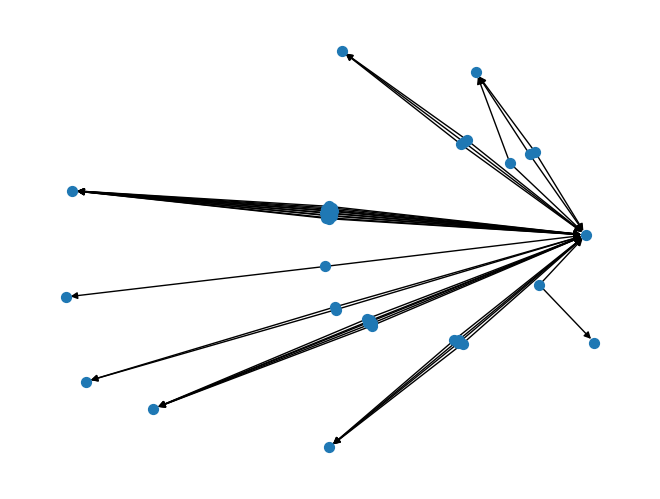

In [15]:
G_nx = nx.DiGraph()

for s, p, o in g:
    if isinstance(o, URIRef):
        G_nx.add_edge(str(s), str(o), label=str(p))

print("NetworkX nodes:", G_nx.number_of_nodes())
print("NetworkX edges:", G_nx.number_of_edges())

# Visualize small subgraph
sub_nodes = list(G_nx.nodes())[:50]
subgraph = G_nx.subgraph(sub_nodes)

plt.figure()
pos = nx.spring_layout(subgraph)
nx.draw(subgraph, pos, node_size=50, with_labels=False)
plt.show()

# =========================

# 12. Serialization

# =========================


In [16]:
# Save graph in different formats
g.serialize("output.ttl", format="turtle")
g.serialize("output.rdf", format="xml")

<Graph identifier=Ndaba37ce4a534d8a924c2890707080d9 (<class 'rdflib.graph.Graph'>)>

# =========================

# 13. Advanced: Reasoning (basic)

# =========================


In [17]:
# Example: find all broader chains manually


def get_broader_chain(graph, node, depth=3):
    chain = []
    current = node
    for _ in range(depth):
        parent = list(graph.objects(current, SKOS.broader))
        if not parent:
            break
        current = parent[0]
        chain.append(current)
    return chain


sample = next(iter(subjects))
print("\nBroader chain:", get_broader_chain(g, sample))


Broader chain: []


# =========================

# 14. Statistics & Insights

# =========================



Top predicates:
predicate
http://www.w3.org/1999/02/22-rdf-syntax-ns#type                 30
http://www.w3.org/2000/01/rdf-schema#label                      30
https://permid.org/ontology/financial/organizationStatusCode    30
https://permid.org/ontology/financial/hasIndustrySector         30
https://permid.org/ontology/financial/foundedYear               30
https://permid.org/ontology/financial/organizationType          30
https://permid.org/ontology/financial/domicileCountry           30
Name: count, dtype: int64


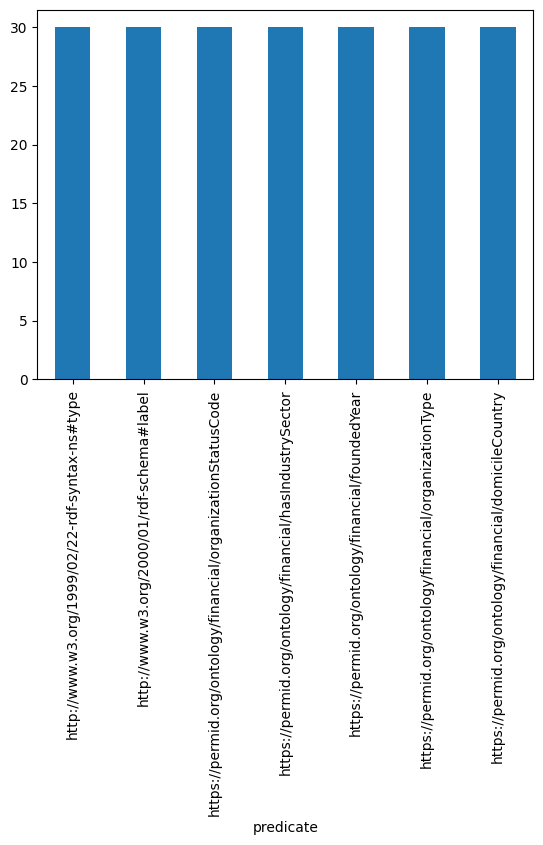

In [18]:
print("\nTop predicates:")
print(predicate_counts.head(30))

# Distribution plot
plt.figure()
predicate_counts.plot(kind="bar")
plt.show()

# =========================

# END

# =========================
